Gen 0, Best = 24994.26
Gen 50, Best = 17558.08
Gen 100, Best = 16135.21
Gen 150, Best = 14682.83
Gen 200, Best = 14588.89
Gen 250, Best = 14573.78
Gen 300, Best = 14573.78
Gen 350, Best = 14573.78
Gen 400, Best = 14573.78
Gen 450, Best = 14573.78
Gen 500, Best = 14573.78
Gen 550, Best = 8353.08
Gen 600, Best = 8353.08
Gen 650, Best = 8353.08
Gen 700, Best = 8353.08
Gen 750, Best = 8353.08
Gen 800, Best = 8353.08
Gen 850, Best = 8353.08
Gen 900, Best = 8353.08
Gen 950, Best = 8353.08
Gen 1000, Best = 8353.08
Gen 1050, Best = 8353.08
Gen 1100, Best = 8353.08
Gen 1150, Best = 8353.08
Gen 1200, Best = 8353.08
Gen 1250, Best = 8353.08
Gen 1300, Best = 8353.08
Gen 1350, Best = 8353.08
Gen 1400, Best = 8353.08
Gen 1450, Best = 8353.08
Gen 1500, Best = 8353.08
Gen 1550, Best = 8353.08
Gen 1600, Best = 8353.08
Gen 1650, Best = 8353.08
Gen 1700, Best = 8353.08
Gen 1750, Best = 8353.08
Gen 1800, Best = 8353.08
Gen 1850, Best = 8353.08
Gen 1900, Best = 8353.08
Gen 1950, Best = 8353.08
Gen 2000, Be

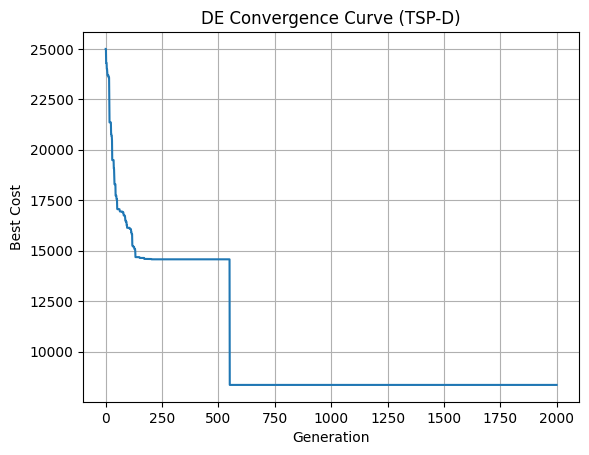

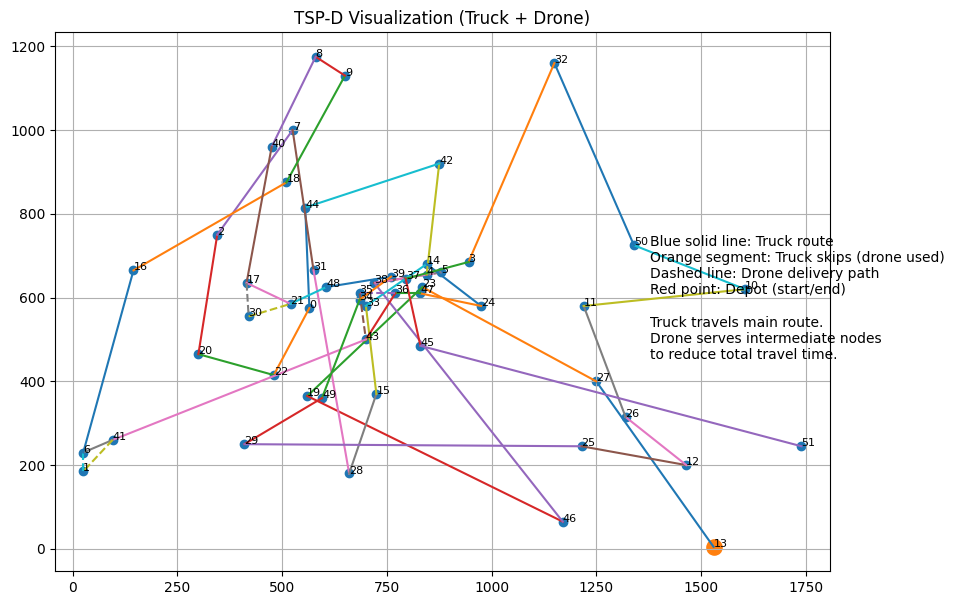

In [ ]:
import numpy as np

DRONE_RANGE = 200
DRONE_SPEED = 1.5
TRUCK_SPEED = 1.0
WAIT_TIME = 5

NP=60
F=0.8
CR=0.9
GEN=2000

# READ TSPLIB
def read_tsp(file_path):
    coords = []
    start = False

    with open(file_path, 'r') as f:
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                coords.append([float(parts[1]), float(parts[2])])

    return np.array(coords)



# DIST MATRIX

def compute_dist_matrix(coords):
    N = len(coords)
    dist = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            dist[i][j] = np.linalg.norm(coords[i] - coords[j])
    return dist



# DECODE
def decode(ind):
    return np.argsort(ind)



# TSP-D COST
def tspd_cost(route, dist):
    total = 0.0
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]

            saving = dist[a][b] + dist[b][c] - dist[a][c]

            if drone_dist <= DRONE_RANGE and saving > 5:
                total += max(truck_dist/TRUCK_SPEED,
                             drone_dist/DRONE_SPEED) + WAIT_TIME
                i += 2
                continue

        total += dist[a][b]
        i += 1

    return total



# 2-OPT

def two_opt(route, dist, max_iter=10):
    best = route.copy()
    best_cost = tspd_cost(best, dist)

    for _ in range(max_iter):
        improved = False
        for i in range(1, len(route)-2):
            for j in range(i+2, len(route)):
                new_route = best.copy()
                new_route[i:j] = best[j-1:i-1:-1]

                new_cost = tspd_cost(new_route, dist)

                if new_cost < best_cost:
                    best = new_route
                    best_cost = new_cost
                    improved = True

        if not improved:
            break

    return best



# PSO MAIN

def PSO_tspd(coords, NP=60, GEN=2000, w=0.7, c1=1.5, c2=1.5):

    dist = compute_dist_matrix(coords)
    N = len(coords)

    # Khởi tạo vị trí và vận tốc
    X = np.random.rand(NP, N)        # position
    V = np.zeros((NP, N))            # velocity

    # pbest
    pbest = X.copy()
    pbest_cost = np.array([tspd_cost(decode(x), dist) for x in X])

    # gbest
    gbest_idx = np.argmin(pbest_cost)
    gbest = pbest[gbest_idx].copy()
    gbest_cost = pbest_cost[gbest_idx]

    history = []

    print(f"Gen 0, Best = {gbest_cost:.2f}")

    for g in range(1, GEN+1):

        for i in range(NP):

            r1 = np.random.rand(N)
            r2 = np.random.rand(N)

            # UPDATE VELOCITY
            V[i] = (w * V[i] +
                    c1 * r1 * (pbest[i] - X[i]) +
                    c2 * r2 * (gbest - X[i]))

            # UPDATE POSITION
            X[i] = X[i] + V[i]

            # giữ trong [0,1]
            X[i] = np.clip(X[i], 0, 1)

            # evaluate
            route = decode(X[i])
            cost = tspd_cost(route, dist)

            # update pbest
            if cost < pbest_cost[i]:
                pbest[i] = X[i].copy()
                pbest_cost[i] = cost

        # update gbest
        best_idx = np.argmin(pbest_cost)
        if pbest_cost[best_idx] < gbest_cost:
            gbest = pbest[best_idx].copy()
            gbest_cost = pbest_cost[best_idx]

        history.append(gbest_cost)

        # LOCAL SEARCH 
        if g > 500 and g % 50 == 0:
            route = decode(gbest)
            route = two_opt(route, dist)
            cost = tspd_cost(route, dist)

            if cost < gbest_cost:
                gbest_cost = cost

        if g % 50 == 0:
            print(f"Gen {g}, Best = {gbest_cost:.2f}")

    return decode(gbest), gbest_cost, history

import matplotlib.pyplot as plt

def plot_convergence(history):
    plt.figure()
    plt.plot(history)
    plt.xlabel("Generation")
    plt.ylabel("Best Cost")
    plt.title("DE Convergence Curve (TSP-D)")
    plt.grid()
    plt.show()

def visualize_tspd(coords, route, dist):
    import matplotlib.pyplot as plt

    DRONE_RANGE = 200
    DRONE_SPEED = 1.5
    TRUCK_SPEED = 1.0
    WAIT_TIME = 5

    plt.figure(figsize=(10, 7))

    route_coords = coords[route]

    # VẼ NODE
    plt.scatter(coords[:, 0], coords[:, 1])

    # depot
    plt.scatter(route_coords[0, 0], route_coords[0, 1], s=120)

    # DUYỆT ROUTE
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]
            saving = dist[a][b] + dist[b][c] - dist[a][c]

            # DÙNG DRONE
            if drone_dist <= DRONE_RANGE and saving > 5:

                # 🚚 truck đi A → C (cam)
                plt.plot([coords[a][0], coords[c][0]],
                         [coords[a][1], coords[c][1]])

                # 🚁 drone đi A → B
                plt.plot([coords[a][0], coords[b][0]],
                         [coords[a][1], coords[b][1]],
                         linestyle='dashed')

                # 🚁 drone đi B → C
                plt.plot([coords[b][0], coords[c][0]],
                         [coords[b][1], coords[c][1]],
                         linestyle='dashed')

                i += 2
                continue

        # TRUCK BÌNH THƯỜNG
        plt.plot([coords[a][0], coords[b][0]],
                 [coords[a][1], coords[b][1]])

        i += 1

    # LABEL NODE
    for idx in route:
        x, y = coords[idx]
        plt.text(x, y, str(idx), fontsize=8)

    # LEGEND 
    explanation = (
        "Blue solid line: Truck route\n"
        "Orange segment: Truck skips (drone used)\n"
        "Dashed line: Drone delivery path\n"
        "Red point: Depot (start/end)\n\n"
        "Truck travels main route.\n"
        "Drone serves intermediate nodes\n"
        "to reduce total travel time."
    )

    plt.gcf().text(0.72, 0.5, explanation, fontsize=10, va='center')

    # FORMA#
    plt.title("TSP-D Visualization (Truck + Drone)")
    plt.axis('equal')
    plt.grid()

    plt.show()

# MAIN

if __name__ == "__main__":
    coords = read_tsp("berlin52.tsp")

    best_route, best_cost, history = PSO_tspd(coords)

    print("\nBest route:", best_route)
    print("Best cost:", best_cost)

    dist = compute_dist_matrix(coords)
    plot_convergence(history)
    visualize_tspd(coords, best_route, dist)